# **Train & Val with CODA (India) · Test with Siriraj (SI) for TB Classification**

## **Import Libraries**

In [1]:
import os
import pandas as pd
import numpy as np
import gc
from pathlib import Path
from typing import List, Dict
import re
import copy
from tqdm.auto import tqdm
import random

# ==== Torch ====
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

# ==== Scikit Learn ====
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    accuracy_score,
    f1_score
)

# ==== Visulization ====
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import seaborn as sns

# ==== Chroma Vector Database ====
import chromadb
from chromadb.config import Settings

## **Project Setup**

In [2]:
# ==== Check Device ==== 
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(torch.version.cuda)
    print(f"✅ Using CUDA device: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu")
    print("⚠️ CUDA not available. Using CPU.")
print(f"Device: {DEVICE}")

12.8
✅ Using CUDA device: NVIDIA GeForce RTX 5060 Laptop GPU
Device: cuda


## **Configuration Parameters**

In [3]:
# ==== Paths ====
DB_PATH:str = "../../../data/chroma_db"

# ==== Vector Database ====
CODA_DB: str = "coda_vector_db"
SI_DB: str = "siriraj_vector_db"
CHROMA_GET_BATCH_SIZE: str = 4096

# ==== Data Splitting ====
n_folds: int = 5
val_size: float = 0.25

# ==== Seed Setting ====
seed: int = 42

# ==== MLP Classification Architecture ====
INPUT_SIZE: int = 512
HIDDEN_SIZE: int = 256 
OUTPUT_SIZE: int = 1
HIDDEN_DIMS: List[int] = [256, 128, 64]
DROPOUT: float = 0.5
THRESHOLD: float = 0.5

# ==== Early Stopping ====
PATIENCE: int = 10
MODE: str = "min"
MONITOR: str = "val_loss"
DELTA: float = 0.001

# ==== Training Loop ====
EPOCHS: int = 30
BATCH_SIZE: int = 16
LEARNING_RATE: float = 3e-4
SHUFFLE: bool = True

# ==== Optimizer ====
OPTIMIZER: str = "adam"

# ==== Loss Function ====
LOSS_FUNCTION: str = "focal_loss"

print("✅ Configuration loaded.")

✅ Configuration loaded.


### Locked Random Seed

In [4]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Environment
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Random seed set to {seed}")

set_seed(seed)
print("✅ All random seeds locked for reproducibility!")

✅ Random seed set to 42
✅ All random seeds locked for reproducibility!


## **Data Preparation**

### Fetch and Build Dataframe

In [5]:
def fetch_all_from_chroma(collection, batch_size: int = 32) -> dict:
    """Fetch all records in batches to avoid SQLite variable limit."""
    total          = collection.count()
    all_embeddings = []
    all_metadatas  = []
    all_ids        = []

    for offset in tqdm(range(0, total, batch_size), desc=f"Fetching {collection.name}"):
        batch = collection.get(
            include = ["embeddings", "metadatas"],
            limit   = batch_size,
            offset  = offset,
        )
        all_embeddings.extend(batch["embeddings"])
        all_metadatas.extend(batch["metadatas"])
        all_ids.extend(batch["ids"])

    return {
        "embeddings" : np.array(all_embeddings, dtype=np.float32),
        "metadatas"  : all_metadatas,
        "ids"        : all_ids,
    }

In [6]:
chroma_client = chromadb.PersistentClient(path=DB_PATH)

coda_collection = chroma_client.get_collection(name=CODA_DB)
si_collection = chroma_client.get_collection(name=SI_DB)

### Build Dataframe from Database

In [7]:
def build_df_from_db(collection, batch_size: int = 40) -> pd.DataFrame:
    results    = fetch_all_from_chroma(collection, batch_size=batch_size)
    embeddings = results["embeddings"]
    metadatas  = results["metadatas"]
    ids        = results["ids"]

    emb_cols = [f"emb_{i}" for i in range(embeddings.shape[1])]
    emb_df   = pd.DataFrame(embeddings, columns=emb_cols)

    meta_df       = pd.DataFrame(metadatas)
    meta_df["id"] = ids

    # ==== Base columns always present ====
    base_cols = ["id", "file_name", "label", "category"]

    # ==== Optional columns — fill with 'unknown' if missing ====
    if "country" not in meta_df.columns:
        meta_df["country"] = "TH"
    if "participant" not in meta_df.columns:
        meta_df["participant"] = None

    df = pd.concat(
        [meta_df[base_cols + ["country", "participant"]], emb_df],
        axis=1
    )
    df["label"] = df["label"].astype(int)
    return df

#### Siriraj

In [8]:
print("📦 Fetching SI dataset...")
df_si = build_df_from_db(si_collection)

print(f"\n✅ SI Dataset")
print(f"   Shape    : {df_si.shape}")
print(f"   Non-TB   : {(df_si['label'] == 0).sum():,}")
print(f"   TB       : {(df_si['label'] == 1).sum():,}")
df_si.iloc[:, :12].head()

📦 Fetching SI dataset...


Fetching siriraj_vector_db:   0%|          | 0/13 [00:00<?, ?it/s]


✅ SI Dataset
   Shape    : (512, 518)
   Non-TB   : 325
   TB       : 187


,id,file_name,label,category,country,participant,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5
0,audio_0,002_03-19.wav,0,Non-TB,TH,None,-1.137581,0.988355,-3.071817,-3.193165,1.261507,-4.150617
1,audio_1,002_03-26.wav,0,Non-TB,TH,None,-1.274177,1.258287,-3.447053,-4.173282,1.359580,-4.710697
2,audio_2,004_07-03.wav,0,Non-TB,TH,None,-1.325635,-0.402892,-2.125412,-5.363134,3.169288,-5.329394
3,audio_3,002_03-20.wav,0,Non-TB,TH,None,-1.511500,3.202736,-0.440748,-6.310660,1.958019,-3.547431
4,audio_4,014_05-01.wav,0,Non-TB,TH,None,-2.206126,1.109271,-1.326759,-4.495713,-0.610894,-3.992732


#### CODA (India)

In [9]:
df_coda = build_df_from_db(coda_collection, batch_size=4096)

df_coda_india = df_coda[df_coda["country"].isin(["IN"])].reset_index(drop=True)

print(f"\n✅ CODA India — Test Set")
print(f"   Shape    : {df_coda_india.shape}")
print(f"   Non-TB   : {(df_coda_india['label'] == 0).sum():,}")
print(f"   TB       : {(df_coda_india['label'] == 1).sum():,}")

df_coda_india.head()

Fetching coda_vector_db:   0%|          | 0/175 [00:00<?, ?it/s]


✅ CODA India — Test Set
   Shape    : (21308, 518)
   Non-TB   : 20,962
   TB       : 346


,id,file_name,label,category,country,participant,emb_0,emb_1,emb_2,emb_3,...,emb_502,emb_503,emb_504,emb_505,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511
0,coda_26,1637859955577-recording-1.wav,0,Non-TB,IN,CODA_TB_1055,-1.469817,0.590092,0.302818,-5.972819,...,4.201343,2.737882,6.889934,3.788598,7.797776,3.945126,8.220690,8.490511,2.680713,4.842937
1,coda_35,1642146461091-recording-1.wav,0,Non-TB,IN,CODA_TB_0213,-2.137336,1.135116,-1.150971,-8.730921,...,2.228129,2.108670,6.564299,4.036091,8.551374,5.657580,9.286470,6.833620,4.272551,4.916615
2,coda_105,1637559572304-recording-1.wav,0,Non-TB,IN,CODA_TB_1055,-3.465061,2.988726,0.364012,-6.116152,...,2.964719,4.299028,4.858132,5.151457,10.435887,-3.050159,6.351467,7.154142,-0.590291,4.186077
3,coda_158,1638668683745-recording-1.wav,0,Non-TB,IN,CODA_TB_1055,-2.001616,1.642918,5.569224,-8.404134,...,7.900712,2.941611,4.822241,1.395416,9.158201,10.434040,8.149642,9.324482,2.823020,6.114316
4,coda_185,1650638261571-recording-1.wav,0,Non-TB,IN,CODA_TB_0543,-2.512010,0.574650,3.987027,-8.736119,...,5.956813,3.033285,4.617104,3.401785,9.224997,10.735485,7.359949,5.982568,4.748195,6.101148


### Build Subject Table

In [10]:
def extract_subject_id(filename):
    """Extracts the subject ID (first 3 digits) from the filename."""
    match = re.match(r"^(\d{3})_", filename)
    if match:
        return match.group(1)
    else:
        # Fallback if pattern doesn't match perfectly
        return filename.split('_')[0]

#### Siriraj

In [11]:
# Add 'subject_id' column
df_si['subject_id'] = df_si['file_name'].apply(extract_subject_id)

print(f"Total samples: {len(df_si)}")
print(f"Unique subjects: {df_si['subject_id'].nunique()}")

Total samples: 512
Unique subjects: 15


#### CODA (India)

In [12]:
# Add 'subject_id' column
df_coda_india['subject_id'] = df_coda_india['participant']

print(f"Total samples: {len(df_coda_india)}")
print(f"Unique participants: {df_coda_india['subject_id'].nunique():,}")

Total samples: 21308
Unique participants: 35


In [13]:
def build_subject_table(df):
    """Creates a DataFrame with one row per subject and their majority label."""
    # Group by subject_id
    # Get the most frequent label (mode)
    subject_df = (
        df.groupby("subject_id")["label"]
        .agg(lambda x: x.mode()[0])
        .reset_index()
        .rename(columns={"label": "subject_label"})
    )
    return subject_df

#### Siriraj

In [14]:
subject_table_si = build_subject_table(df_si)

X_si_subj = subject_table_si["subject_id"].values
y_si_subj = subject_table_si["subject_label"].values

print(subject_table_si)
print("="*80)
print(f"\nTotal Unique Subjects: {len(X_si_subj)}")

   subject_id  subject_label
0         001              0
1         002              0
2         003              0
3         004              0
4         005              0
5         006              1
6         007              0
7         008              1
8         009              1
9         011              1
10        012              1
11        013              0
12        014              0
13        015              1
14        016              1

Total Unique Subjects: 15


#### CODA (India)

In [15]:
subject_table_coda_india = build_subject_table(df_coda_india)

X_coda_india_in_subj = subject_table_coda_india["subject_id"].values
y_coda_india_in_subj = subject_table_coda_india["subject_label"].values

print(subject_table_coda_india.head())
print("="*80)
print(f"\nTotal Unique Subjects: {len(X_coda_india_in_subj)}")

     subject_id  subject_label
0  CODA_TB_0008              0
1  CODA_TB_0027              0
2  CODA_TB_0051              0
3  CODA_TB_0096              0
4  CODA_TB_0134              0

Total Unique Subjects: 35


### Helper Function

In [16]:
def filter_by_subjects(df: pd.DataFrame, subject_ids) -> pd.DataFrame:
    return df[df["subject_id"].isin(set(subject_ids))].reset_index(drop=True)


def print_detailed_stats(df: pd.DataFrame, subj_ids, split_name: str, total_n: int):
    subset         = df[df["subject_id"].isin(subj_ids)]
    tb_df          = subset[subset["label"] == 1]
    nontb_df       = subset[subset["label"] == 0]
    tb_subjs       = sorted(tb_df["subject_id"].unique().tolist())
    nontb_subjs    = sorted(nontb_df["subject_id"].unique().tolist())
    ratio          = len(subj_ids) / total_n

    print(f"  {split_name.upper():5s} SET : {len(subj_ids):>2} subjects ({ratio:.2%})")
    print(f"   ├─ TB    (1) : {len(tb_df):>4} segments | IDs: {', '.join(tb_subjs)}")
    print(f"   └─ NonTB (0) : {len(nontb_df):>4} segments | IDs: {', '.join(nontb_subjs)}")

## **Stratified K Fold for Splitting Data**

In [17]:
def build_cv_folds(
    df_si       : pd.DataFrame,   # SI         — Test source
    df_coda     : pd.DataFrame,   # CODA       — Train/Val source
    n_folds     : int   = 5,
    val_size    : float = 0.25,
    random_seed : int   = 42,
) -> dict:

    # ==== CODA subject table (for train/val splits) ====
    subject_table_coda = build_subject_table(df_coda)
    X_coda_subj  = subject_table_coda["subject_id"].values
    y_coda_subj  = subject_table_coda["subject_label"].values
    n_coda_total = len(X_coda_subj)

    # ==== SI subject table (for rotating test splits) ====
    subject_table_si = build_subject_table(df_si)
    X_si_subj  = subject_table_si["subject_id"].values
    y_si_subj  = subject_table_si["subject_label"].values
    n_si_total = len(X_si_subj)

    print(f"\n{'='*80}")
    print(f"  Building {n_folds}-fold combined splits  (CODA for Train/Val · SI test)")
    print(f"{'='*80}")
    print(f"  CODA subjects : {n_coda_total}  | clips: {len(df_coda):,}")
    print(f"  SI subjects   : {n_si_total}     | clips: {len(df_si):,}")

    # ==== SKF on CODA subjects (train/val) ====
    coda_skf    = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_seed)

    # ==== SKF on SI subjects (rotating test) ====
    si_skf      = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_seed)

    all_folds   = []
    coda_splits = list(coda_skf.split(X_coda_subj, y_coda_subj))
    si_splits   = list(si_skf.split(X_si_subj, y_si_subj))

    for fold_idx, (
        (coda_trainval_idx, coda_unused_idx),   # ← outer fold gives us 80% CODA for train+val
        (si_unused_idx,     si_test_idx)         # ← outer fold gives us 20% SI for test
    ) in enumerate(zip(coda_splits, si_splits), start=1):

        # ==== CODA: use the 80% trainval portion → split into train/val ====
        coda_tv_subj = X_coda_subj[coda_trainval_idx]
        y_tv         = y_coda_subj[coda_trainval_idx]

        inner = StratifiedShuffleSplit(
            n_splits=1,
            test_size=val_size,              # 0.25 of 80% = 20% overall
            random_state=random_seed + fold_idx
        )
        inner_train_idx, inner_val_idx = next(inner.split(coda_tv_subj, y_tv))

        train_subj = coda_tv_subj[inner_train_idx]   # ~60% of all CODA subjects
        val_subj   = coda_tv_subj[inner_val_idx]     # ~20% of all CODA subjects

        # ==== SI: use the 20% test portion ====
        si_test_subj = X_si_subj[si_test_idx]        # ~20% of SI subjects

        # ==== Leakage checks ====
        assert set(train_subj).isdisjoint(set(val_subj)),      f"Fold {fold_idx}: CODA train/val overlap!"
        # Note: CODA and SI have completely different subject IDs so cross-dataset
        # leakage is impossible, but we check anyway for safety
        assert set(train_subj).isdisjoint(set(si_test_subj)),  f"Fold {fold_idx}: train/SI-test overlap!"
        assert set(val_subj).isdisjoint(set(si_test_subj)),    f"Fold {fold_idx}: val/SI-test overlap!"

        # ==== Filter DataFrames ====
        train_df = filter_by_subjects(df_coda, train_subj)
        val_df   = filter_by_subjects(df_coda, val_subj)
        test_df  = filter_by_subjects(df_si,   si_test_subj)

        # ==== Stats ====
        tb_train    = (train_df["label"] == 1).sum()
        nontb_train = (train_df["label"] == 0).sum()
        tb_val      = (val_df["label"] == 1).sum()
        nontb_val   = (val_df["label"] == 0).sum()
        tb_test     = (test_df["label"] == 1).sum()
        nontb_test  = (test_df["label"] == 0).sum()

        # Ratios based on CLIP counts (not subject counts) to match expected output
        ratio_train = len(train_df) / len(df_coda)
        ratio_val   = len(val_df)   / len(df_coda)
        ratio_test  = len(test_df)  / len(df_si)

        print(f"\n── Fold {fold_idx} ──")
        print(f"  Train(CODA) : {len(train_df):>7,} segments ({ratio_train:.1%})"
              f" | TB: {tb_train:>7,} segments | NonTB: {nontb_train:>7,} segments")
        print(f"  Val(CODA)   : {len(val_df):>7,} segments ({ratio_val:.1%})"
              f" | TB: {tb_val:>7,} segments | NonTB: {nontb_val:>7,} segments")
        print(f"  Test(SI)    : {len(test_df):>7,} segments ({ratio_test:.1%})"
              f" | TB: {tb_test:>7,} segments | NonTB: {nontb_test:>7,} segments")

        all_folds.append({
            "fold"       : fold_idx,
            "seed"       : random_seed + fold_idx,
            "train"      : train_df,
            "val"        : val_df,
            "test"       : test_df,
            "train_subj" : sorted(train_subj.tolist()),
            "val_subj"   : sorted(val_subj.tolist()),
            "test_subj"  : sorted(si_test_subj.tolist()),
        })

    print(f"\n{'='*80}")
    print(f"  ✅ NO SUBJECT LEAKAGE  (CODA train/val disjoint; SI test is independent)")
    print(f"{'='*80}\n")

    return {
        "subject_table_coda" : subject_table_coda,
        "subject_table_si"   : subject_table_si,
        "folds"              : all_folds,
    }

In [18]:
splits = build_cv_folds(
    df_si, 
    df_coda_india, 
    n_folds=n_folds, 
    val_size=val_size, 
    random_seed=seed
)


  Building 5-fold combined splits  (CODA for Train/Val · SI test)
  CODA subjects : 35  | clips: 21,308
  SI subjects   : 15     | clips: 512

── Fold 1 ──
  Train(CODA) :  20,845 segments (97.8%) | TB:     330 segments | NonTB:  20,515 segments
  Val(CODA)   :     149 segments (0.7%) | TB:      16 segments | NonTB:     133 segments
  Test(SI)    :      84 segments (16.4%) | TB:      42 segments | NonTB:      42 segments

── Fold 2 ──
  Train(CODA) :   4,534 segments (21.3%) | TB:      17 segments | NonTB:   4,517 segments
  Val(CODA)   :  13,476 segments (63.2%) | TB:     329 segments | NonTB:  13,147 segments
  Test(SI)    :     109 segments (21.3%) | TB:      37 segments | NonTB:      72 segments


c:\Users\OMEN\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



── Fold 3 ──
  Train(CODA) :   4,159 segments (19.5%) | TB:       1 segments | NonTB:   4,158 segments
  Val(CODA)   :   3,546 segments (16.6%) | TB:     329 segments | NonTB:   3,217 segments
  Test(SI)    :     140 segments (27.3%) | TB:      20 segments | NonTB:     120 segments

── Fold 4 ──
  Train(CODA) :  19,249 segments (90.3%) | TB:      16 segments | NonTB:  19,233 segments
  Val(CODA)   :      20 segments (0.1%) | TB:       1 segments | NonTB:      19 segments
  Test(SI)    :      55 segments (10.7%) | TB:       5 segments | NonTB:      50 segments

── Fold 5 ──
  Train(CODA) :  18,576 segments (87.2%) | TB:      16 segments | NonTB:  18,560 segments
  Val(CODA)   :     678 segments (3.2%) | TB:     329 segments | NonTB:     349 segments
  Test(SI)    :     124 segments (24.2%) | TB:      83 segments | NonTB:      41 segments

  ✅ NO SUBJECT LEAKAGE  (CODA train/val disjoint; SI test is independent)



## **Embedding Extraction & Fold Data Preparation**

In [19]:
EMB_COLS = [c for c in df_si.columns if c.startswith("emb_")]

def get_fold_XY(fold: dict):
    """Extract all 5 splits as numpy arrays from a fold dict."""
    def to_XY(df):
        X = df[EMB_COLS].values.astype(np.float32)
        y = df["label"].values.astype(int)
        return X, y

    X_train,    y_train    = to_XY(fold["train"])
    X_val,      y_val      = to_XY(fold["val"])
    X_test,     y_test     = to_XY(fold["test"])

    return X_train, y_train, X_val, y_val, X_test, y_test

fold_data = []
# Verify all folds
for fold in splits["folds"]:
    X_train, y_train, X_val, y_val, X_test, y_test = get_fold_XY(fold)
    fold_data.append(get_fold_XY(fold))
    print(f"Fold {fold['fold']} → "
          f"Train: {X_train.shape} | Val: {X_val.shape} | "
          f"Test: {X_test.shape}")

Fold 1 → Train: (20845, 512) | Val: (149, 512) | Test: (84, 512)
Fold 2 → Train: (4534, 512) | Val: (13476, 512) | Test: (109, 512)
Fold 3 → Train: (4159, 512) | Val: (3546, 512) | Test: (140, 512)
Fold 4 → Train: (19249, 512) | Val: (20, 512) | Test: (55, 512)
Fold 5 → Train: (18576, 512) | Val: (678, 512) | Test: (124, 512)


## **MLP Classification**

In [20]:
class MLPModel(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: List[int], dropout: float):
        super().__init__()

        self.input_dim    = input_dim
        self.hidden_dims  = hidden_dims
        self.dropout      = dropout

        layers   = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim
        
        # Output layer — single logit for binary classification
        layers.append(nn.Linear(prev_dim, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

    def get_model_info(self) -> Dict:
        """Return architecture summary."""
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return {
            "input_dim"       : self.input_dim,
            "hidden_dims"     : self.hidden_dims,
            "dropout"         : self.dropout,
            "total_params"    : total,
            "trainable_params": trainable,
        }

## **Training MLP Classification Model**

### Early Stopping

In [21]:
class EarlyStopping:
    def __init__(self, patience: int, mode: str , monitor: str, delta: float, verbose: bool = True):
        self.patience      = patience
        self.delta         = delta
        self.verbose       = verbose
        self.mode          = mode
        self.monitor       = monitor
        self.best_val_loss = float("inf")
        self.best_state    = None
        self.bad_epochs    = 0
        self.best_epoch    = 0
        self.early_stop    = False

    def __call__(self, val_loss: float, model: nn.Module, epoch: int) -> bool:
        improved = val_loss < (self.best_val_loss - self.delta)
        if improved:
            if self.verbose:
                print(f"  ✅ Val loss improved: {self.best_val_loss:.4f} → {val_loss:.4f}  (epoch {epoch+1})")
            self.best_val_loss = val_loss
            self.best_state    = copy.deepcopy(model.state_dict())
            self.bad_epochs    = 0
            self.best_epoch    = epoch
        else:
            self.bad_epochs += 1
            if self.verbose:
                print(f"  ❌ No improvement in val loss: {val_loss:.4f} (best: {self.best_val_loss:.4f})  [bad epochs: {self.bad_epochs}/{self.patience}]")
            if self.bad_epochs >= self.patience:
                if self.verbose:
                    print(f"  ⏰ Early stopping triggered after {self.bad_epochs} bad epochs.")
                self.early_stop = True
            return self.early_stop
    
    def restore_best_weights(self, model: nn.Module) -> None:
        """Load the best weights back into the model."""
        if self.best_state is not None:
            model.load_state_dict(self.best_state)
            if self.verbose:
                print(f"\n✅ Best weights restored from epoch {self.best_epoch+1} "
                      f"(val loss: {self.best_val_loss:.4f})")

### Training Loop

In [22]:
all_fold_results = []

print("\n" + "="*80)
print(f"Starting Training on {n_folds} Folds...")
print(f"Device: {DEVICE}")
print("="*80)

for fold_idx in range(n_folds):
    print(f"\n{'='*60}")
    print(f"  Fold {fold_idx+1} / {n_folds}")
    print(f"{'='*60}")

    X_train, y_train, X_val, y_val, X_test, y_test = fold_data[fold_idx]

    X_train_t = torch.FloatTensor(X_train).to(DEVICE)
    y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(DEVICE)
    X_val_t   = torch.FloatTensor(X_val).to(DEVICE)
    y_val_t   = torch.FloatTensor(y_val).unsqueeze(1).to(DEVICE)
    X_test_t  = torch.FloatTensor(X_test).to(DEVICE)
    y_test_t  = torch.FloatTensor(y_test).unsqueeze(1).to(DEVICE)

    train_dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
    val_dataset   = torch.utils.data.TensorDataset(X_val_t, y_val_t)
    test_dataset  = torch.utils.data.TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

    # ==== Model & Optimizer ====
    model = MLPModel(input_dim=INPUT_SIZE, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    early_stopping = EarlyStopping(
        patience = PATIENCE,
        mode     = MODE,
        monitor  = MONITOR,
        delta    = DELTA,
        verbose  = True
    )

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    # ==== Training Loop ====
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        correct, total = 0, 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = F.binary_cross_entropy_with_logits(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss /= total
        train_acc = correct / total

        # ==== Validation ====
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = F.binary_cross_entropy_with_logits(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)

                preds = (torch.sigmoid(outputs) > 0.5).float()
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        val_loss /= total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        if early_stopping(val_loss, model, epoch):
            early_stopping.restore_best_weights(model)
            print(f"  ⏰ Stopping early at epoch {epoch+1}")
            break
        print("-"*60)
    
    # Store fold results
    all_fold_results.append({
        "fold"       : fold_idx+1,
        "model"      : model,
        "history"    : history,
        "best_val_loss": early_stopping.best_val_loss,
        "best_epoch" : early_stopping.best_epoch + 1,
        "final_val_acc" : history["val_acc"][early_stopping.best_epoch] if history["val_acc"] else 0,
    })

print("\n✅ Training Complete.")


Starting Training on 5 Folds...
Device: cuda

  Fold 1 / 5
Epoch 1/30 | Train Loss: 0.1987, Train Acc: 0.9409 | Val Loss: 0.3998, Val Acc: 0.8926
  ✅ Val loss improved: inf → 0.3998  (epoch 1)
------------------------------------------------------------
Epoch 2/30 | Train Loss: 0.0537, Train Acc: 0.9844 | Val Loss: 0.5102, Val Acc: 0.8926
  ❌ No improvement in val loss: 0.5102 (best: 0.3998)  [bad epochs: 1/10]
------------------------------------------------------------
Epoch 3/30 | Train Loss: 0.0406, Train Acc: 0.9867 | Val Loss: 0.6226, Val Acc: 0.8926
  ❌ No improvement in val loss: 0.6226 (best: 0.3998)  [bad epochs: 2/10]
------------------------------------------------------------
Epoch 4/30 | Train Loss: 0.0333, Train Acc: 0.9899 | Val Loss: 0.6171, Val Acc: 0.8926
  ❌ No improvement in val loss: 0.6171 (best: 0.3998)  [bad epochs: 3/10]
------------------------------------------------------------
Epoch 5/30 | Train Loss: 0.0307, Train Acc: 0.9911 | Val Loss: 0.7518, Val Acc:

### Visualization of Early Stopping Training per Fold

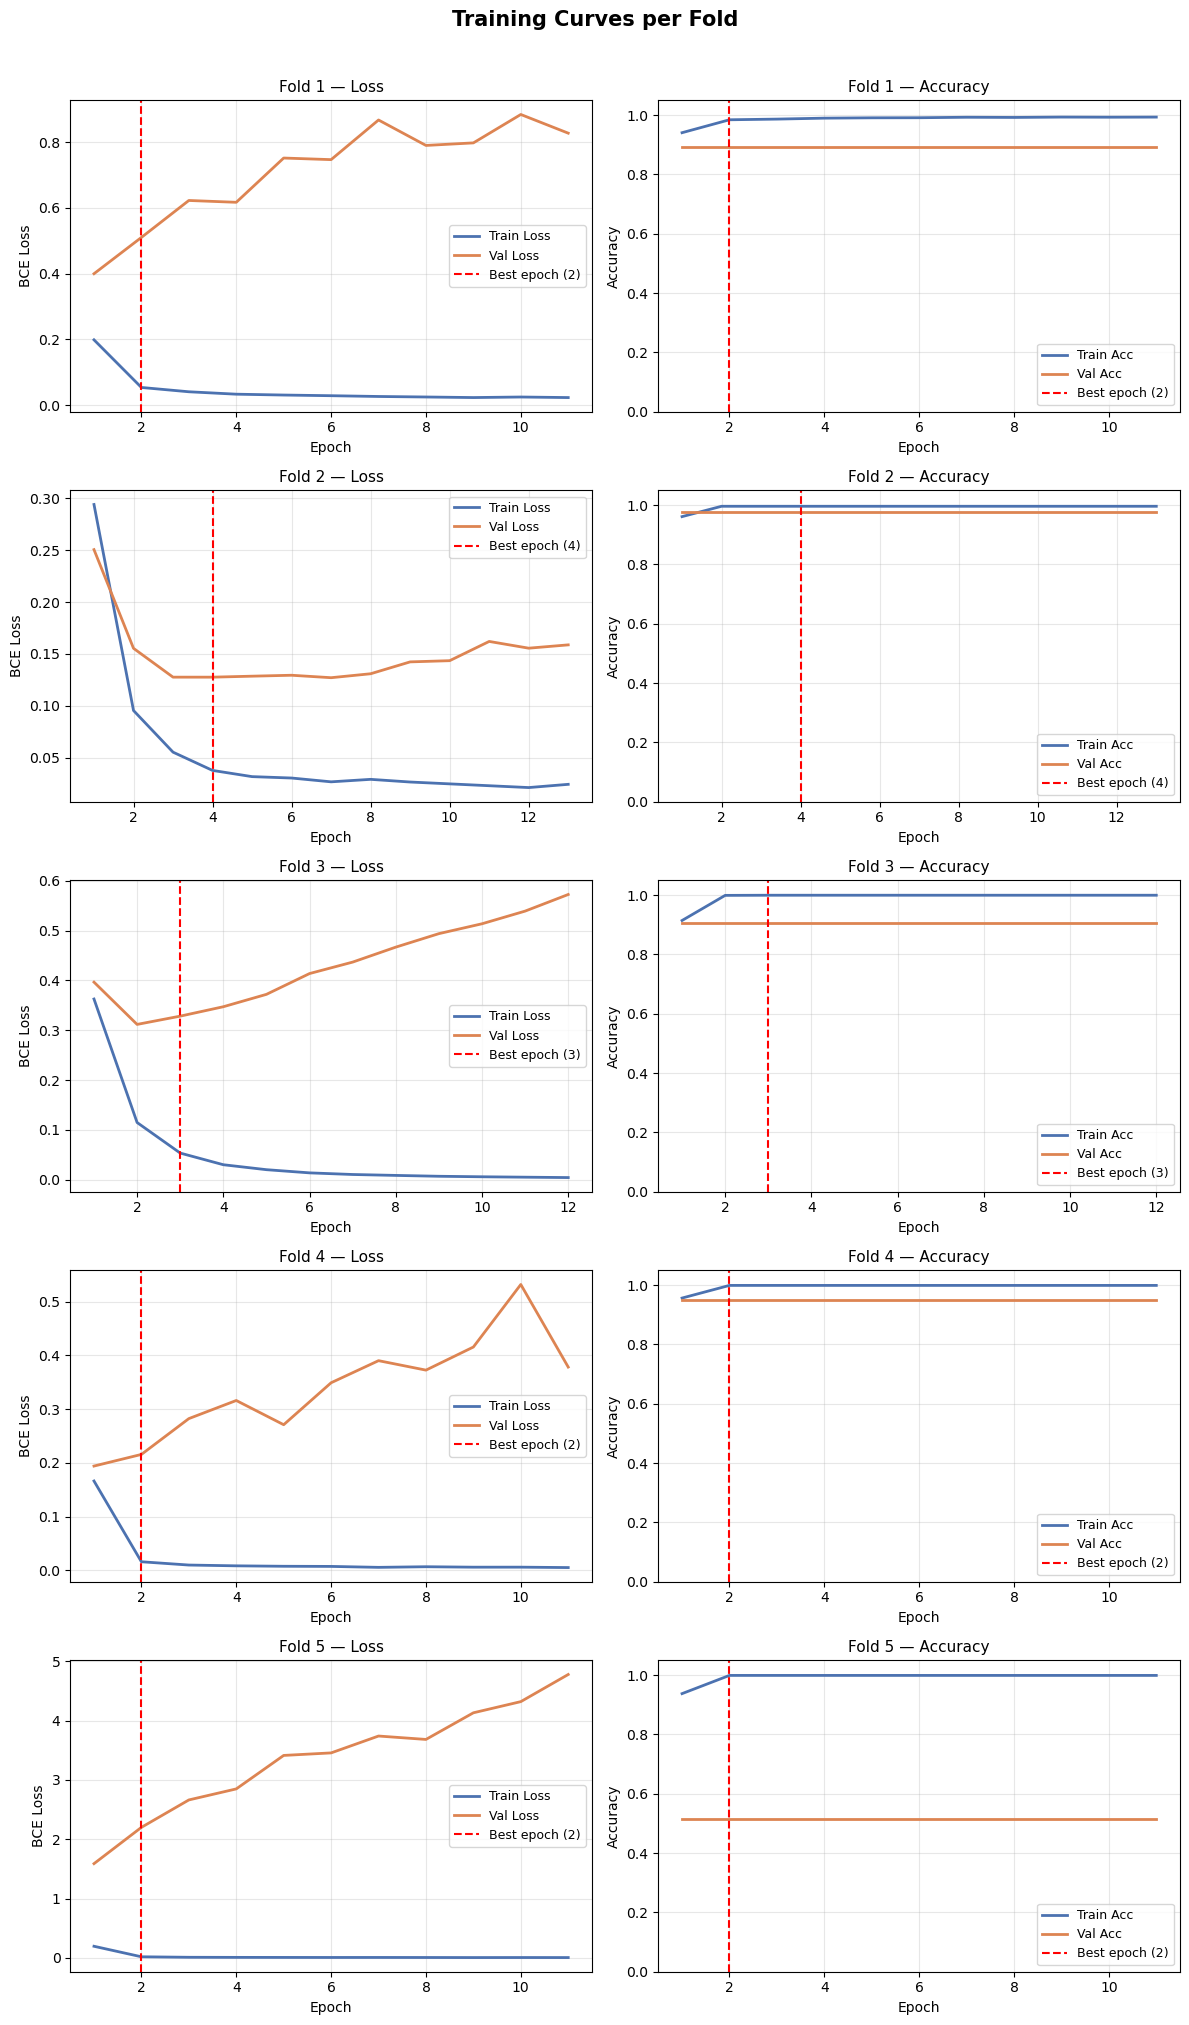

In [23]:
fig, axes = plt.subplots(
    nrows = n_folds,
    ncols = 2,
    figsize = (12, 4 * n_folds),
)

fig.suptitle("Training Curves per Fold", fontsize=15, fontweight="bold", y=1.01)

for i, result in enumerate(all_fold_results):
    history = result["history"]
    best_epoch = result["best_epoch"]
    fold_num = result["fold"]

    epochs = range(1, len(history["train_loss"]) + 1)

    # ==== Loss Curves ====
    ax_loss = axes[i, 0]
    ax_loss.plot(epochs, history["train_loss"], label="Train Loss",
                 color="#4C72B0", lw=2)
    ax_loss.plot(epochs, history["val_loss"],   label="Val Loss",
                 color="#DD8452", lw=2)
    ax_loss.axvline(best_epoch + 1, color="red", linestyle="--", lw=1.5,
                    label=f"Best epoch ({best_epoch + 1})")
    ax_loss.set_title(f"Fold {fold_num} — Loss", fontsize=11)
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("BCE Loss")
    ax_loss.legend(fontsize=9)
    ax_loss.grid(True, alpha=0.3)

    # ==== Accuracy Curves ====
    ax_acc = axes[i, 1]
    ax_acc.plot(epochs, history["train_acc"], label="Train Acc",
                color="#4C72B0", lw=2)
    ax_acc.plot(epochs, history["val_acc"],   label="Val Acc",
                color="#DD8452", lw=2)
    ax_acc.axvline(best_epoch + 1, color="red", linestyle="--", lw=1.5,
                   label=f"Best epoch ({best_epoch + 1})")
    ax_acc.set_title(f"Fold {fold_num} — Accuracy", fontsize=11)
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_ylim([0, 1.05])
    ax_acc.legend(fontsize=9)
    ax_acc.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **Evaluation Model**

### Evaluation with Classification Report per Fold

In [24]:
fold_probs = []   # sigmoid probabilities (N_test,) per fold
fold_y_tests = []

for fold_idx, result in enumerate(all_fold_results):
    model = result["model"]
    _, _, _, _, X_test, y_test = fold_data[fold_idx]
    X_test_t = torch.FloatTensor(X_test).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logits = model(X_test_t).squeeze().cpu().numpy()
    probs = 1 / (1 + np.exp(-logits))   # sigmoid
    fold_probs.append(np.atleast_1d(probs))
    fold_y_tests.append(np.asarray(y_test).astype(int))

fold_probs     = np.array(fold_probs, dtype=object)        # (n_folds, N_test)
print(f"✅ Predictions from {len(fold_probs)} folds  "
      f"({sum(len(y) for y in fold_y_tests)} total test samples)")

✅ Predictions from 5 folds  (512 total test samples)


In [27]:
# ── Per-fold metrics summary ───────────────────────────────────────────────────
print("\n" + "="*80)
print("SUMMARY OF ALL FOLDS (Per-Fold Test Performance)")
print("="*80 + "\n")

fold_summary = []

for i, (probs, y_true, result) in enumerate(
        zip(fold_probs, fold_y_tests, all_fold_results), start=1):
    fpr, tpr, thresholds = roc_curve(y_true, probs)
    j_idx  = np.argmax(tpr - fpr)
    thresh = float(thresholds[j_idx])

    preds          = (probs >= thresh).astype(int)
    cm             = confusion_matrix(y_true, preds)
    tn, fp, fn, tp = cm.ravel()
    sens  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    auroc = roc_auc_score(y_true, probs)
    auprc = average_precision_score(y_true, probs)
    acc   = accuracy_score(y_true, preds)
    f1    = f1_score(y_true, preds, zero_division=0)

    fold_summary.append({
        "Fold": i, "AUROC": f"{auroc:.4f}", "AUPRC": f"{auprc:.4f}",
        "Sensitivity": f"{sens:.3f}", "Specificity": f"{spec:.3f}",
        "Threshold": f"{thresh:.4f}", "Best Epoch": result["best_epoch"] + 1,
        "_auroc": auroc, "_auprc": auprc, "_sens": sens, "_spec": spec, "_acc": acc, "_f1": f1
    })

cols = ["Fold", "AUROC", "AUPRC", "Sensitivity", "Specificity", "Threshold", "Best Epoch"]
print(pd.DataFrame(fold_summary)[cols].to_string(index=False))

aurocs = [r["_auroc"] for r in fold_summary]
auprcs = [r["_auprc"] for r in fold_summary]
accs   = [r["_acc"]   for r in fold_summary]
f1s    = [r["_f1"]    for r in fold_summary]
senss  = [r["_sens"]  for r in fold_summary]
specs  = [r["_spec"]  for r in fold_summary]

print(f"\n{'-'*80}")
print(f"Mean AUROC       : {np.mean(aurocs):.4f} ± {np.std(aurocs):.4f}")
print(f"Mean AUPRC       : {np.mean(auprcs):.4f} ± {np.std(auprcs):.4f}")
print(f"Mean Accuracy    : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Mean F1 Score    : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
print(f"Mean Sensitivity : {np.mean(senss):.3f} ± {np.std(senss):.3f}")
print(f"Mean Specificity : {np.mean(specs):.3f} ± {np.std(specs):.3f}")
print(f"{'-'*80}")


SUMMARY OF ALL FOLDS (Per-Fold Test Performance)

 Fold  AUROC  AUPRC Sensitivity Specificity Threshold  Best Epoch
    1 0.8197 0.7804       0.786       0.786    0.0291           2
    2 0.5758 0.4456       0.676       0.569    0.0445           4
    3 0.2492 0.0958       0.000       1.000       inf           3
    4 0.3040 0.1092       0.200       0.940    0.0625           2
    5 0.6100 0.7476       0.880       0.415    0.0529           2

--------------------------------------------------------------------------------
Mean AUROC       : 0.5118 ± 0.2101
Mean AUPRC       : 0.4357 ± 0.2961
Mean Accuracy    : 0.7694 ± 0.0974
Mean F1 Score    : 0.4713 ± 0.3171
Mean Sensitivity : 0.508 ± 0.345
Mean Specificity : 0.742 ± 0.221
--------------------------------------------------------------------------------


### Visualization of Evaluation with AUROC Curves and Confusion Matrix per Fold

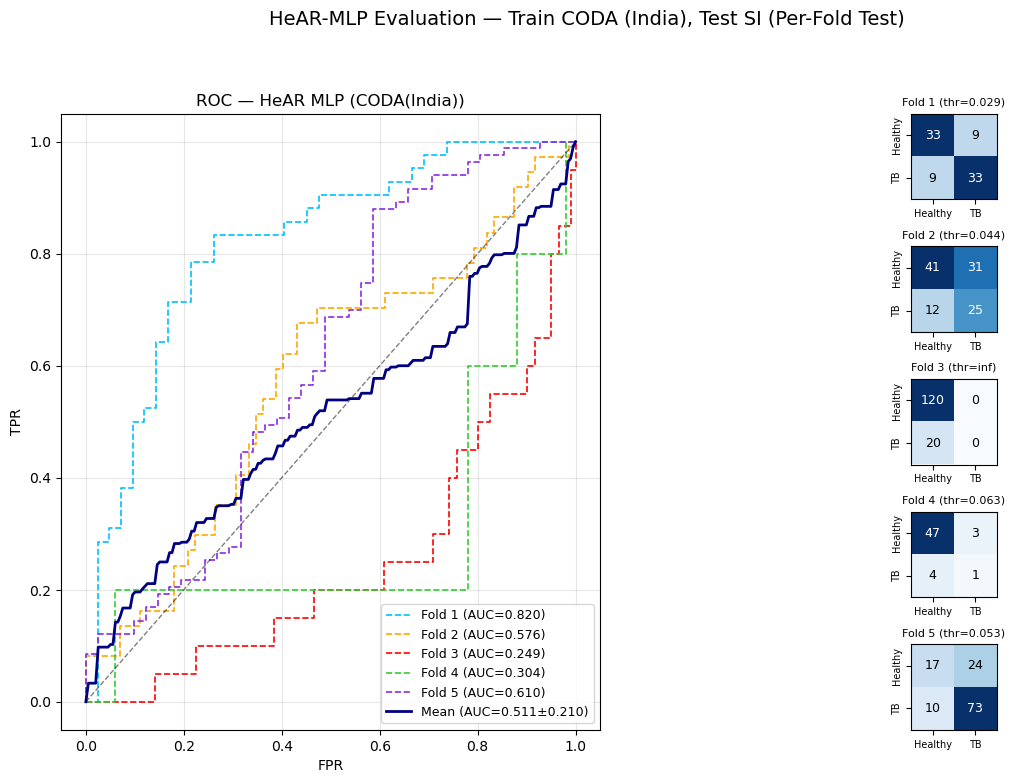

In [26]:
# ── ROC curves + confusion matrices ────────────────────────────────────────────
FOLD_COLORS = ["#00BFFF", "#FFA500", "#FF0000", "#32CD32", "#8A2BE2"]
mean_fpr = np.linspace(0, 1, 200)
fold_fprs, fold_tprs, fold_aucs = [], [], []

for y_true, probs in zip(fold_y_tests, fold_probs):
    fpr, tpr, _ = roc_curve(y_true, probs)
    fold_fprs.append(fpr); fold_tprs.append(tpr); fold_aucs.append(auc(fpr, tpr))

interp_tprs = [np.interp(mean_fpr, f, t) for f, t in zip(fold_fprs, fold_tprs)]
mean_tpr    = np.mean(interp_tprs, axis=0); mean_tpr[0] = 0.0
mean_auc    = auc(mean_fpr, mean_tpr); std_auc = np.std(fold_aucs)      

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.4, 1], wspace=0.35)

# LEFT: ROC
ax_roc = fig.add_subplot(gs[0])
for i, (fpr, tpr, a) in enumerate(zip(fold_fprs, fold_tprs, fold_aucs)):
    ax_roc.plot(fpr, tpr, color=FOLD_COLORS[i], lw=1.2, ls="--",
                label=f"Fold {i+1} (AUC={a:.3f})")
ax_roc.plot(mean_fpr, mean_tpr, color="navy", lw=2,
            label=f"Mean (AUC={mean_auc:.3f}±{std_auc:.3f})")
ax_roc.plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
ax_roc.set_title("ROC — HeAR MLP (CODA(India))"); ax_roc.legend(fontsize=9)
ax_roc.grid(alpha=0.3)

# RIGHT: Confusion matrices
gs_cm = gridspec.GridSpecFromSubplotSpec(n_folds, 1, subplot_spec=gs[1], hspace=0.55)
for i, (y_true, probs) in enumerate(zip(fold_y_tests, fold_probs)):
    fpr, tpr, ths = roc_curve(y_true, probs)
    thresh = float(ths[np.argmax(tpr - fpr)])
    preds = (probs >= thresh).astype(int)
    cm = confusion_matrix(y_true, preds)
    ax = fig.add_subplot(gs_cm[i])
    ax.imshow(cm, cmap=plt.cm.Blues, vmin=0)
    ax.set_title(f"Fold {i+1} (thr={thresh:.3f})", fontsize=8)
    ax.set_xticks([0,1]); ax.set_xticklabels(["Healthy","TB"], fontsize=7)
    ax.set_yticks([0,1]); ax.set_yticklabels(["Healthy","TB"], fontsize=7, rotation=90, va="center")
    mid = cm.max() / 2
    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r, c]), ha="center", va="center", fontsize=9,
                    color="white" if cm[r, c] > mid else "black")

plt.suptitle("HeAR-MLP Evaluation — Train CODA (India), Test SI (Per-Fold Test)", fontsize=14, y=1.01)
plt.show()